In [1]:

# ============================================================
# 0. Imports and settings
# ============================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

DATA_PATH = Path("df_base.csv")
COMPONENT_FEATURE_DIR = Path("component_feature_selection_outputs")
OUTPUT_DIR = Path("pce_one_stage_vs_two_stage_canonical207_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

SELECTED_FEATURE_FILES = {
    "Jsc": COMPONENT_FEATURE_DIR / "jsc_selected_top20.csv",
    "Voc": COMPONENT_FEATURE_DIR / "voc_selected_top20.csv",
    "FF": COMPONENT_FEATURE_DIR / "ff_selected_top30.csv",
}
EXPECTED_SELECTED_COUNTS = {"Jsc": 20, "Voc": 20, "FF": 30}

# Main repeated held-out evaluation.
HOLDOUT_SEEDS = list(range(10))
TEST_SIZE = 0.20

# Inner CV for leakage-controlled Stage-1 OOF predictions.
INNER_CV_SPLITS = 5

# Random forest settings: unchanged from notebooks 01 and 03.
N_ESTIMATORS = 200
MIN_SAMPLES_LEAF = 1
RF_RANDOM_STATE = 42
N_JOBS_RF = -1

# Optional selected-model permutation importance.
RUN_PERMUTATION_IMPORTANCE = True
PERMUTATION_SEEDS = HOLDOUT_SEEDS
PERMUTATION_N_REPEATS = 5

MAX_MISSING_RATIO = 0.50
EXPECTED_ALLIN_FEATURES = 207

TARGETS = {
    "Jsc": "jv.default_Jsc",
    "Voc": "jv.default_Voc",
    "FF": "jv.default_FF",
}
PCE_TARGET = "jv.default_PCE"
ALL_TARGET_COLS = list(TARGETS.values()) + [PCE_TARGET]

print("Settings")
print("-" * 70)
print("DATA_PATH:", DATA_PATH.resolve())
print("COMPONENT_FEATURE_DIR:", COMPONENT_FEATURE_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("HOLDOUT_SEEDS:", HOLDOUT_SEEDS)
print("TEST_SIZE:", TEST_SIZE)
print("INNER_CV_SPLITS:", INNER_CV_SPLITS)
print("RUN_PERMUTATION_IMPORTANCE:", RUN_PERMUTATION_IMPORTANCE)


Settings
----------------------------------------------------------------------
DATA_PATH: /Users/rosylu/Desktop/PVK/notebooks_final/df_base.csv
COMPONENT_FEATURE_DIR: /Users/rosylu/Desktop/PVK/notebooks_final/component_feature_selection_outputs
OUTPUT_DIR: /Users/rosylu/Desktop/PVK/notebooks_final/pce_one_stage_vs_two_stage_canonical207_outputs
HOLDOUT_SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
TEST_SIZE: 0.2
INNER_CV_SPLITS: 5
RUN_PERMUTATION_IMPORTANCE: True


In [2]:
# ============================================================
# 1. Load dataset
# ============================================================

df_base = pd.read_csv(DATA_PATH, low_memory=False)
print("df_base shape:", df_base.shape)
print("First 10 columns:", df_base.columns[:10].tolist())


df_base shape: (3182, 411)
First 10 columns: ['m_def', 'ref.internal_sample_id', 'ref.ID', 'ref.ID_temp', 'ref.name_of_person_entering_the_data', 'ref.data_entered_by_author', 'ref.DOI_number', 'ref.lead_author', 'ref.publication_date', 'ref.journal']


In [3]:

# ============================================================
# 2. Build the two agreed Level-3 features
# ============================================================

for c in [
    "PVK_thickness_clean",
    "ETL_thickness_clean",
    "HTL_thickness_clean",
    "BC_thickness_clean",
    "perovskite_bandgap_clean",
    "jv.default_Jsc",
    "jv.default_Voc",
    "jv.default_FF",
    "jv.default_PCE",
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
]:
    if c in df_base.columns:
        df_base[c] = pd.to_numeric(df_base[c], errors="coerce")


def num_col(d, col):
    if col in d.columns:
        return pd.to_numeric(d[col], errors="coerce")
    return pd.Series(np.nan, index=d.index)


def safe_div(a, b):
    return (a / b.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)


def add_agreed_level3_features(d):
    d = d.copy()

    pvk = num_col(d, "PVK_thickness_clean")
    etl = num_col(d, "ETL_thickness_clean")
    htl = num_col(d, "HTL_thickness_clean")
    bc = num_col(d, "BC_thickness_clean")

    d["Absorber_to_ETL_ratio"] = safe_div(pvk, etl)
    d["ff_PVK_fraction_of_total_stack"] = safe_div(
        pvk, pvk + etl + htl + bc
    )
    return d


df_base = add_agreed_level3_features(df_base)
df_base = df_base.replace([np.inf, -np.inf], np.nan)

LEVEL3_FEATURES = [
    "Absorber_to_ETL_ratio",
    "ff_PVK_fraction_of_total_stack",
]

print("Agreed Level-3 features:")
for c in LEVEL3_FEATURES:
    print(" -", c, "present =", c in df_base.columns)


Agreed Level-3 features:
 - Absorber_to_ETL_ratio present = True
 - ff_PVK_fraction_of_total_stack present = True


In [4]:

# ============================================================
# 3. Load frozen component-selected feature lists
# ============================================================

def load_selected_feature_csv(path, target_name, expected_count):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {target_name} selected-feature file: {path}\n"
            "Run notebook 04 through the feature-export cells first, and keep "
            "the component_feature_selection_outputs folder beside this notebook."
        )

    table = pd.read_csv(path)
    if "selected_feature" in table.columns:
        feature_col = "selected_feature"
    elif table.shape[1] == 1:
        feature_col = table.columns[0]
    else:
        raise ValueError(
            f"{path} must contain a 'selected_feature' column or exactly one column."
        )

    features = (
        table[feature_col]
        .dropna()
        .astype(str)
        .tolist()
    )

    if len(features) != len(set(features)):
        duplicates = pd.Series(features)[pd.Series(features).duplicated()].tolist()
        raise ValueError(
            f"Duplicate features found in {target_name} list: {duplicates}"
        )

    if len(features) != expected_count:
        raise ValueError(
            f"{target_name} list contains {len(features)} features; "
            f"expected {expected_count}."
        )

    return features


SELECTED_FEATURES = {
    target_name: load_selected_feature_csv(
        SELECTED_FEATURE_FILES[target_name],
        target_name,
        EXPECTED_SELECTED_COUNTS[target_name],
    )
    for target_name in ["Jsc", "Voc", "FF"]
}


def unique_keep_order(cols):
    return list(dict.fromkeys(cols))


# This union is the selected input for both direct PCE prediction and
# the Stage-2 base descriptors.
PCE_SELECTED_UNION_FEATURES = unique_keep_order(
    SELECTED_FEATURES["Jsc"]
    + SELECTED_FEATURES["Voc"]
    + SELECTED_FEATURES["FF"]
)

print("Frozen component feature counts:")
for target_name in ["Jsc", "Voc", "FF"]:
    print(f" - {target_name}: {len(SELECTED_FEATURES[target_name])}")

print(
    "PCE selected union:",
    len(PCE_SELECTED_UNION_FEATURES),
    "unique features after removing overlap",
)

pd.Series(
    PCE_SELECTED_UNION_FEATURES,
    name="selected_feature",
).to_csv(
    OUTPUT_DIR / "pce_selected_union_features.csv",
    index=False,
)


Frozen component feature counts:
 - Jsc: 20
 - Voc: 20
 - FF: 30
PCE selected union: 37 unique features after removing overlap


In [5]:

# ============================================================
# 4. Build aligned PCE dataset and feature matrices
# ============================================================

PREPROCESSING_ADDED_COLUMNS = {
    "ETL_layers", "ETL_thickness_values", "ETL_n_layers",
    "ETL_n_thickness", "ETL_valid",
    "HTL_layers", "HTL_thickness_values", "HTL_n_layers",
    "HTL_n_thickness", "HTL_valid",
    "BC_layers", "BC_thickness_values", "BC_n_layers",
    "BC_n_thickness", "BC_valid",
    "ETL_thickness_clean", "HTL_thickness_clean", "BC_thickness_clean",
    "PVK_thickness_clean", "PVK_thickness_note", "PVK_valid",
    "all_layer_match", "perovskite_bandgap_clean", "baseline_complete",
}

DIRECT_OUTCOME_COLUMNS = {
    # Default, forward, and reverse JV outcomes
    "jv.default_PCE", "jv.default_Jsc", "jv.default_Voc", "jv.default_FF",
    "jv.forward_scan_PCE", "jv.forward_scan_Jsc",
    "jv.forward_scan_Voc", "jv.forward_scan_FF",
    "jv.reverse_scan_PCE", "jv.reverse_scan_Jsc",
    "jv.reverse_scan_Voc", "jv.reverse_scan_FF",

    # Other measured-curve results
    "jv.forward_scan_Vmp", "jv.forward_scan_Jmp",
    "jv.reverse_scan_Vmp", "jv.reverse_scan_Jmp",
    "jv.forward_scan_series_resistance",
    "jv.forward_scan_shunt_resistance",
    "jv.reverse_scan_series_resistance",
    "jv.reverse_scan_shunt_resistance",
    "jv.hysteresis_index",

    # Stabilised and EQE results
    "stabilised.performance_PCE", "stabilised.performance_Jsc",
    "stabilised.performance_Voc", "stabilised.performance_FF",
    "stabilised.performance_Jmp", "stabilised.performance_Vmp",
    "stabilised.performance_procedure_metrics",
    "eqe.integrated_Jsc",

    # Flags inferred from measured PCE trajectories
    "stability.PCE_burn_in_observed",
    "outdoor.PCE_burn_in_observed",
}

RAW_TO_CLEAN_REPLACEMENTS = {
    "perovskite.band_gap": "perovskite_bandgap_clean",
    "perovskite.thickness": "PVK_thickness_clean",
    "etl.thickness": "ETL_thickness_clean",
    "htl.thickness_list": "HTL_thickness_clean",
    "backcontact.thickness_list": "BC_thickness_clean",
}

LEVEL2_HELPERS = [
    "ETL_n_layers",
    "HTL_n_layers",
    "BC_n_layers",
]

missing_targets = [c for c in ALL_TARGET_COLS if c not in df_base.columns]
if missing_targets:
    raise ValueError("Missing target columns: " + ", ".join(missing_targets))

Y_all = df_base[ALL_TARGET_COLS].copy()
for col in ALL_TARGET_COLS:
    Y_all[col] = pd.to_numeric(Y_all[col], errors="coerce")

# PCE experiment uses the same rows with PCE and all three JV components.
mask = Y_all[ALL_TARGET_COLS].notna().all(axis=1)

df_model = (
    df_base.loc[mask]
    .replace({pd.NA: np.nan})
    .reset_index(drop=True)
)
Y_comp = (
    Y_all.loc[mask, list(TARGETS.values())]
    .reset_index(drop=True)
)
y_pce = (
    Y_all.loc[mask, PCE_TARGET]
    .reset_index(drop=True)
)

# Canonical 207-feature all-in definition, identical to notebooks 01 and 03.
missing_ratio = df_base.isna().mean()
eligible_raw_features = [
    column
    for column in df_base.columns
    if missing_ratio[column] < MAX_MISSING_RATIO
    and column not in PREPROCESSING_ADDED_COLUMNS
    and column not in DIRECT_OUTCOME_COLUMNS
    and column not in ALL_TARGET_COLS
    and column not in LEVEL3_FEATURES
    and column != "m_def"
    and not column.startswith("ref.")
    and not column.endswith("link_raw_data")
]

ALLIN_FEATURES = [
    RAW_TO_CLEAN_REPLACEMENTS.get(column, column)
    for column in eligible_raw_features
]
ALLIN_FEATURES += LEVEL2_HELPERS + LEVEL3_FEATURES

assert len(eligible_raw_features) == 202
assert len(ALLIN_FEATURES) == EXPECTED_ALLIN_FEATURES
assert len(ALLIN_FEATURES) == len(set(ALLIN_FEATURES))
assert set(RAW_TO_CLEAN_REPLACEMENTS).isdisjoint(ALLIN_FEATURES)
assert set(RAW_TO_CLEAN_REPLACEMENTS.values()).issubset(ALLIN_FEATURES)
assert set(LEVEL2_HELPERS).issubset(ALLIN_FEATURES)
assert set(LEVEL3_FEATURES).issubset(ALLIN_FEATURES)
assert not set(ALLIN_FEATURES).intersection(DIRECT_OUTCOME_COLUMNS)
assert not any(column.startswith("ref.") for column in ALLIN_FEATURES)
assert any(column.startswith("stability.") for column in ALLIN_FEATURES)
assert any(column.startswith("outdoor.") for column in ALLIN_FEATURES)

missing_selected_columns = {
    target_name: [
        feature
        for feature in SELECTED_FEATURES[target_name]
        if feature not in df_model.columns
    ]
    for target_name in ["Jsc", "Voc", "FF"]
}
missing_selected_columns = {
    target_name: missing
    for target_name, missing in missing_selected_columns.items()
    if missing
}
if missing_selected_columns:
    raise ValueError(
        "Selected features missing from df_base: "
        + str(missing_selected_columns)
    )

selected_not_in_allin = [
    feature
    for feature in PCE_SELECTED_UNION_FEATURES
    if feature not in ALLIN_FEATURES
]
if selected_not_in_allin:
    raise ValueError(
        "The selected union contains features outside canonical all-in: "
        + ", ".join(selected_not_in_allin)
    )

X_allin = df_model[ALLIN_FEATURES].copy()
X_pce_selected = df_model[PCE_SELECTED_UNION_FEATURES].copy()

feature_audit = pd.DataFrame([
    {
        "set": "Jsc selected",
        "n_features": len(SELECTED_FEATURES["Jsc"]),
    },
    {
        "set": "Voc selected",
        "n_features": len(SELECTED_FEATURES["Voc"]),
    },
    {
        "set": "FF selected",
        "n_features": len(SELECTED_FEATURES["FF"]),
    },
    {
        "set": "PCE selected union",
        "n_features": len(PCE_SELECTED_UNION_FEATURES),
    },
    {
        "set": "Canonical all-in",
        "n_features": len(ALLIN_FEATURES),
    },
])
display(feature_audit)
feature_audit.to_csv(OUTPUT_DIR / "feature_audit.csv", index=False)

print("PCE-aligned samples:", len(df_model))
print("Canonical all-in features:", X_allin.shape[1])
print("PCE selected union features:", X_pce_selected.shape[1])
print("Selected Level-3 features:", [
    c for c in LEVEL3_FEATURES if c in PCE_SELECTED_UNION_FEATURES
])

print("\nPCE selected union:")
for feature in PCE_SELECTED_UNION_FEATURES:
    print(" -", feature)

pd.Series(
    ALLIN_FEATURES,
    name="allin_feature",
).to_csv(
    OUTPUT_DIR / "allin_feature_list.csv",
    index=False,
)


,set,n_features
0,Jsc selected,20
1,Voc selected,20
2,FF selected,30
3,PCE selected union,37
4,Canonical all-in,207


PCE-aligned samples: 3182
Canonical all-in features: 207
PCE selected union features: 37
Selected Level-3 features: ['Absorber_to_ETL_ratio', 'ff_PVK_fraction_of_total_stack']

PCE selected union:
 - perovskite_bandgap_clean
 - Absorber_to_ETL_ratio
 - PVK_thickness_clean
 - perovskite_deposition.quenching_induced_crystallisation
 - HTL_thickness_clean
 - etl.deposition_procedure
 - htl.stack_sequence
 - perovskite.composition_short_form
 - cell.area_measured
 - etl.stack_sequence
 - backcontact.stack_sequence
 - ETL_thickness_clean
 - perovskite_deposition.synthesis_atmosphere
 - perovskite_deposition.thermal_annealing_time
 - BC_thickness_clean
 - perovskite_deposition.procedure
 - perovskite_deposition.thermal_annealing_temperature
 - htl.deposition_procedure
 - jv.light_masked_cell
 - jv.test_atmosphere
 - perovskite.composition_b_ions
 - perovskite_deposition.solvents
 - perovskite.composition_leadfree
 - perovskite_deposition.quenching_media
 - perovskite.composition_a_ions
 - pe

In [6]:

# ============================================================
# 5. Modelling helpers
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_rf_pipeline(X, rf_random_state=RF_RANDOM_STATE):
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")), 
    ])

    categorical_transformer = Pipeline([
        ("to_object", FunctionTransformer(
            lambda x: x.astype(object), validate=False
        )),
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("to_string", FunctionTransformer(lambda x: x.astype(str), validate=False)),
        ("onehot", make_onehot_encoder()),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ])

    model = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=rf_random_state,
        n_jobs=N_JOBS_RF,
    )

    return Pipeline([
        ("prep", preprocessor),
        ("model", model),
    ])


def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_regression(y_true, y_pred):
    return {
        "PCE_R2": float(r2_score(y_true, y_pred)),
        "PCE_RMSE": float(rmse_score(y_true, y_pred)),
    }


def evaluate_component(y_true, y_pred):
    return {
        "test_R2": float(r2_score(y_true, y_pred)),
        "test_RMSE": float(rmse_score(y_true, y_pred)),
    }


def pce_formula(jsc, voc, ff):
    """Perovskite DB convention: Jsc [mA/cm2], Voc [V], FF [fraction] -> PCE [%]."""
    return np.asarray(jsc) * np.asarray(voc) * np.asarray(ff)


def count_encoded_features_after_fit(pipeline):
    prep = pipeline.named_steps["prep"]
    try:
        num_cols = prep.transformers_[0][2]
        cat_cols = prep.transformers_[1][2]
        n_num = len(num_cols)
        if len(cat_cols) == 0:
            return int(n_num)
        cat_pipe = prep.named_transformers_["cat"]
        onehot = cat_pipe.named_steps["onehot"]
        n_cat = int(sum(len(cats) for cats in onehot.categories_))
        return int(n_num + n_cat)
    except Exception:
        return np.nan



def get_component_feature_matrix(component):
    if component not in SELECTED_FEATURES:
        raise ValueError("Unknown component: " + str(component))

    columns = SELECTED_FEATURES[component]
    label = f"{component}_selected_{len(columns)}"
    return df_model[columns].copy(), label


In [7]:

# ============================================================
# 6. Main experiment
# ============================================================

pce_rows = []
stage1_rows = []

pce_partial_path = OUTPUT_DIR / "pce_model_results_PARTIAL.csv"
pce_final_path = OUTPUT_DIR / "pce_model_results.csv"
stage1_final_path = OUTPUT_DIR / "pce_stage1_component_results.csv"

for split_seed in HOLDOUT_SEEDS:
    print("\n" + "=" * 100)
    print(f"PCE held-out split seed {split_seed}")
    print("=" * 100)

    idx = np.arange(len(y_pce))
    train_idx, test_idx = train_test_split(
        idx,
        test_size=TEST_SIZE,
        random_state=split_seed,
        shuffle=True,
    )

    y_train_pce = y_pce.iloc[train_idx].reset_index(drop=True)
    y_test_pce = y_pce.iloc[test_idx].reset_index(drop=True)
    Y_train_comp = Y_comp.iloc[train_idx].reset_index(drop=True)
    Y_test_comp = Y_comp.iloc[test_idx].reset_index(drop=True)

    # ------------------------------------------------------------
    # 1) one_stage_all_in_PCE
    # ------------------------------------------------------------
    X_train_all = X_allin.iloc[train_idx].reset_index(drop=True)
    X_test_all = X_allin.iloc[test_idx].reset_index(drop=True)

    model_all = make_rf_pipeline(X_train_all, rf_random_state=RF_RANDOM_STATE)
    model_all.fit(X_train_all, y_train_pce)
    pred_all = model_all.predict(X_test_all)
    metrics = evaluate_regression(y_test_pce, pred_all)
    pce_rows.append({
        "split_seed": split_seed,
        "model": "one_stage_all_in_PCE",
        "stage": "one_stage",
        "feature_input": "canonical_207_all_in",
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_raw_features": X_train_all.shape[1],
        "n_encoded_features_after_fit": count_encoded_features_after_fit(model_all),
        **metrics,
    })
    print(f"  one_stage_all_in_PCE              | R2={metrics['PCE_R2']:.4f} | RMSE={metrics['PCE_RMSE']:.4f}")

    # ------------------------------------------------------------
    # 2) one_stage_selected_union_PCE
    # ------------------------------------------------------------
    X_train_sel = X_pce_selected.iloc[train_idx].reset_index(drop=True)
    X_test_sel = X_pce_selected.iloc[test_idx].reset_index(drop=True)

    model_sel = make_rf_pipeline(X_train_sel, rf_random_state=RF_RANDOM_STATE)
    model_sel.fit(X_train_sel, y_train_pce)
    pred_sel = model_sel.predict(X_test_sel)
    metrics = evaluate_regression(y_test_pce, pred_sel)
    pce_rows.append({
        "split_seed": split_seed,
        "model": "one_stage_selected_union_PCE",
        "stage": "one_stage",
        "feature_input": "union_of_Jsc20_Voc20_FF30",
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_raw_features": X_train_sel.shape[1],
        "n_encoded_features_after_fit": count_encoded_features_after_fit(model_sel),
        **metrics,
    })
    print(f"  one_stage_selected_union_PCE        | R2={metrics['PCE_R2']:.4f} | RMSE={metrics['PCE_RMSE']:.4f}")

    # ------------------------------------------------------------
    # 3) oracle_true_JV_formula_PCE
    # ------------------------------------------------------------
    pred_oracle_formula = pce_formula(
        Y_test_comp[TARGETS["Jsc"]],
        Y_test_comp[TARGETS["Voc"]],
        Y_test_comp[TARGETS["FF"]],
    )
    metrics = evaluate_regression(y_test_pce, pred_oracle_formula)
    pce_rows.append({
        "split_seed": split_seed,
        "model": "oracle_true_JV_formula_PCE",
        "stage": "oracle",
        "feature_input": "true_test_Jsc_Voc_FF_formula",
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_raw_features": 3,
        "n_encoded_features_after_fit": 3,
        **metrics,
    })
    print(f"  oracle_true_JV_formula_PCE      | R2={metrics['PCE_R2']:.4f} | RMSE={metrics['PCE_RMSE']:.4f}")

    # ------------------------------------------------------------
    # 4) Stage-1 component predictions for two-stage model
    #    Training meta-features = inner-CV OOF predictions.
    #    Test meta-features = held-out predictions from final Stage-1 models.
    # ------------------------------------------------------------
    inner_cv = KFold(n_splits=INNER_CV_SPLITS, shuffle=True, random_state=split_seed)

    train_stage1_pred = pd.DataFrame(index=np.arange(len(train_idx)))
    test_stage1_pred = pd.DataFrame(index=np.arange(len(test_idx)))

    for component, target_col in TARGETS.items():
        X_comp_all, comp_feature_input = get_component_feature_matrix(component)
        X_comp_train = X_comp_all.iloc[train_idx].reset_index(drop=True)
        X_comp_test = X_comp_all.iloc[test_idx].reset_index(drop=True)
        y_comp_train = Y_train_comp[target_col].reset_index(drop=True)
        y_comp_test = Y_test_comp[target_col].reset_index(drop=True)

        comp_model_for_oof = make_rf_pipeline(X_comp_train, rf_random_state=RF_RANDOM_STATE)
        oof_pred = cross_val_predict(
            comp_model_for_oof,
            X_comp_train,
            y_comp_train,
            cv=inner_cv,
            n_jobs=1,
        )

        comp_final_model = make_rf_pipeline(X_comp_train, rf_random_state=RF_RANDOM_STATE)
        comp_final_model.fit(X_comp_train, y_comp_train)
        test_pred = comp_final_model.predict(X_comp_test)

        train_stage1_pred[f"{component}_hat"] = oof_pred
        test_stage1_pred[f"{component}_hat"] = test_pred

        comp_metrics = evaluate_component(y_comp_test, test_pred)
        train_oof_r2 = float(r2_score(y_comp_train, oof_pred))
        train_oof_rmse = float(rmse_score(y_comp_train, oof_pred))

        stage1_rows.append({
            "split_seed": split_seed,
            "component": component,
            "target": target_col,
            "feature_input": comp_feature_input,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_raw_features": X_comp_train.shape[1],
            "n_encoded_features_after_fit": count_encoded_features_after_fit(comp_final_model),
            "train_oof_R2": train_oof_r2,
            "train_oof_RMSE": train_oof_rmse,
            **comp_metrics,
        })
        print(
            f"    Stage1 {component:<3} ({comp_feature_input}) | "
            f"test R2={comp_metrics['test_R2']:.4f} | test RMSE={comp_metrics['test_RMSE']:.4f}"
        )

    # ------------------------------------------------------------
    # 5) two_stage_selected_union_plus_OOF_JV_PCE
    # ------------------------------------------------------------
    X_train_two = pd.concat(
        [X_train_sel.reset_index(drop=True), train_stage1_pred.reset_index(drop=True)],
        axis=1,
    )
    X_test_two = pd.concat(
        [X_test_sel.reset_index(drop=True), test_stage1_pred.reset_index(drop=True)],
        axis=1,
    )

    model_two = make_rf_pipeline(X_train_two, rf_random_state=RF_RANDOM_STATE)
    model_two.fit(X_train_two, y_train_pce)
    pred_two = model_two.predict(X_test_two)
    metrics = evaluate_regression(y_test_pce, pred_two)
    pce_rows.append({
        "split_seed": split_seed,
        "model": "two_stage_selected_union_plus_OOF_JV_PCE",
        "stage": "two_stage",
        "feature_input": "selected_union_plus_OOF_or_test_predicted_Jsc_Voc_FF",
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_raw_features": X_train_two.shape[1],
        "n_encoded_features_after_fit": count_encoded_features_after_fit(model_two),
        **metrics,
    })
    print(f"  two_stage_selected_union_plus_OOF_JV_PCE | R2={metrics['PCE_R2']:.4f} | RMSE={metrics['PCE_RMSE']:.4f}")

    # Save partial after every seed, so timeout does not lose results.
    pd.DataFrame(pce_rows).to_csv(pce_partial_path, index=False)

pce_results = pd.DataFrame(pce_rows)
stage1_results = pd.DataFrame(stage1_rows)

pce_results.to_csv(pce_final_path, index=False)
stage1_results.to_csv(stage1_final_path, index=False)

print("\nSaved:", pce_final_path)
print("Saved:", stage1_final_path)



PCE held-out split seed 0
  one_stage_all_in_PCE              | R2=0.6613 | RMSE=2.7981
  one_stage_selected_union_PCE        | R2=0.6580 | RMSE=2.8117
  oracle_true_JV_formula_PCE      | R2=0.9857 | RMSE=0.5742
    Stage1 Jsc (Jsc_selected_20) | test R2=0.6978 | test RMSE=2.4569
    Stage1 Voc (Voc_selected_20) | test R2=0.5512 | test RMSE=0.0878
    Stage1 FF  (FF_selected_30) | test R2=0.4936 | test RMSE=0.0780
  two_stage_selected_union_plus_OOF_JV_PCE | R2=0.6639 | RMSE=2.7870

PCE held-out split seed 1
  one_stage_all_in_PCE              | R2=0.6543 | RMSE=2.7847
  one_stage_selected_union_PCE        | R2=0.6534 | RMSE=2.7881
  oracle_true_JV_formula_PCE      | R2=0.9687 | RMSE=0.8378
    Stage1 Jsc (Jsc_selected_20) | test R2=0.6688 | test RMSE=2.5591
    Stage1 Voc (Voc_selected_20) | test R2=0.6602 | test RMSE=0.0836
    Stage1 FF  (FF_selected_30) | test R2=0.4384 | test RMSE=0.0780
  two_stage_selected_union_plus_OOF_JV_PCE | R2=0.6574 | RMSE=2.7722

PCE held-out split seed

In [8]:

# ============================================================
# 7. Summary tables
# ============================================================

pce_summary = (
    pce_results
    .groupby("model")
    .agg(
        n_splits=("split_seed", "nunique"),
        PCE_R2_mean=("PCE_R2", "mean"),
        PCE_R2_std=("PCE_R2", "std"),
        PCE_R2_min=("PCE_R2", "min"),
        PCE_R2_max=("PCE_R2", "max"),
        PCE_R2_range=("PCE_R2", lambda x: x.max() - x.min()),
        PCE_RMSE_mean=("PCE_RMSE", "mean"),
        PCE_RMSE_std=("PCE_RMSE", "std"),
        n_raw_features_mean=("n_raw_features", "mean"),
        n_encoded_features_mean=("n_encoded_features_after_fit", "mean"),
    )
    .reset_index()
    .sort_values("PCE_R2_mean", ascending=False)
)

display(pce_summary)
pce_summary.to_csv(OUTPUT_DIR / "pce_model_summary.csv", index=False)

pivot_r2 = pce_results.pivot(index="split_seed", columns="model", values="PCE_R2")

delta_rows = []

def add_delta(comparison_name, model_a, model_b):
    # Delta = model_a - model_b within the same split seed.
    if model_a in pivot_r2.columns and model_b in pivot_r2.columns:
        d = pivot_r2[model_a] - pivot_r2[model_b]
        delta_rows.append({
            "comparison": comparison_name,
            "delta_definition": f"{model_a} minus {model_b}",
            "n_splits": d.notna().sum(),
            "Delta_R2_mean": d.mean(),
            "Delta_R2_median": d.median(),
            "Delta_R2_std": d.std(ddof=1),
            "Delta_R2_min": d.min(),
            "Delta_R2_max": d.max(),
            "model_a_win_rate": (d > 0).mean(),
            "within_0.01_rate": (d.abs() <= 0.01).mean(),
            "within_0.02_rate": (d.abs() <= 0.02).mean(),
        })

add_delta(
    "Main question: does two-stage beat one-stage selected?",
    "two_stage_selected_union_plus_OOF_JV_PCE",
    "one_stage_selected_union_PCE",
)
add_delta(
    "Baseline: does selected-union one-stage match canonical all-in?",
    "one_stage_selected_union_PCE",
    "one_stage_all_in_PCE",
)

delta_summary = pd.DataFrame(delta_rows)
display(delta_summary)
delta_summary.to_csv(OUTPUT_DIR / "pce_paired_delta_summary.csv", index=False)

stage1_summary = (
    stage1_results
    .groupby(["component", "feature_input"])
    .agg(
        n_splits=("split_seed", "nunique"),
        test_R2_mean=("test_R2", "mean"),
        test_R2_std=("test_R2", "std"),
        test_R2_min=("test_R2", "min"),
        test_R2_max=("test_R2", "max"),
        test_RMSE_mean=("test_RMSE", "mean"),
        test_RMSE_std=("test_RMSE", "std"),
        train_oof_R2_mean=("train_oof_R2", "mean"),
        train_oof_RMSE_mean=("train_oof_RMSE", "mean"),
        n_raw_features_mean=("n_raw_features", "mean"),
        n_encoded_features_mean=("n_encoded_features_after_fit", "mean"),
    )
    .reset_index()
    .sort_values("component")
)

display(stage1_summary)
stage1_summary.to_csv(OUTPUT_DIR / "pce_stage1_component_summary.csv", index=False)


,model,n_splits,PCE_R2_mean,PCE_R2_std,PCE_R2_min,PCE_R2_max,PCE_R2_range,PCE_RMSE_mean,PCE_RMSE_std,n_raw_features_mean,n_encoded_features_mean
2,oracle_true_JV_formula_PCE,10,0.938792,0.032056,0.891490,0.985736,0.094247,1.137792,0.323450,3.0,3.0
0,one_stage_all_in_PCE,10,0.680276,0.029681,0.621274,0.712689,0.091415,2.694869,0.118169,207.0,3385.0
1,one_stage_selected_union_PCE,10,0.676891,0.030045,0.615352,0.711108,0.095756,2.709106,0.119024,37.0,1955.0
3,two_stage_selected_union_plus_OOF_JV_PCE,10,0.671250,0.024229,0.619718,0.695568,0.075851,2.733783,0.097289,40.0,1958.0


,comparison,delta_definition,n_splits,Delta_R2_mean,Delta_R2_median,Delta_R2_std,Delta_R2_min,Delta_R2_max,model_a_win_rate,within_0.01_rate,within_0.02_rate
0,Main question: does two-stage beat one-stage s...,two_stage_selected_union_plus_OOF_JV_PCE minus...,10,-0.005642,-0.006274,0.008818,-0.018497,0.00597,0.3,0.7,1.0
1,Baseline: does selected-union one-stage match ...,one_stage_selected_union_PCE minus one_stage_a...,10,-0.003385,-0.002733,0.003224,-0.009766,0.00159,0.1,1.0,1.0


,component,feature_input,n_splits,test_R2_mean,test_R2_std,test_R2_min,test_R2_max,test_RMSE_mean,test_RMSE_std,train_oof_R2_mean,train_oof_RMSE_mean,n_raw_features_mean,n_encoded_features_mean
0,FF,FF_selected_30,10,0.490938,0.034076,0.427459,0.529678,0.074430,0.003056,0.465369,0.076694,30.0,1854.3
1,Jsc,Jsc_selected_20,10,0.694312,0.039195,0.632487,0.754782,2.551299,0.117812,0.651084,2.815525,20.0,1025.6
2,Voc,Voc_selected_20,10,0.638789,0.059682,0.551220,0.704070,0.083545,0.008423,0.593623,0.092006,20.0,975.9


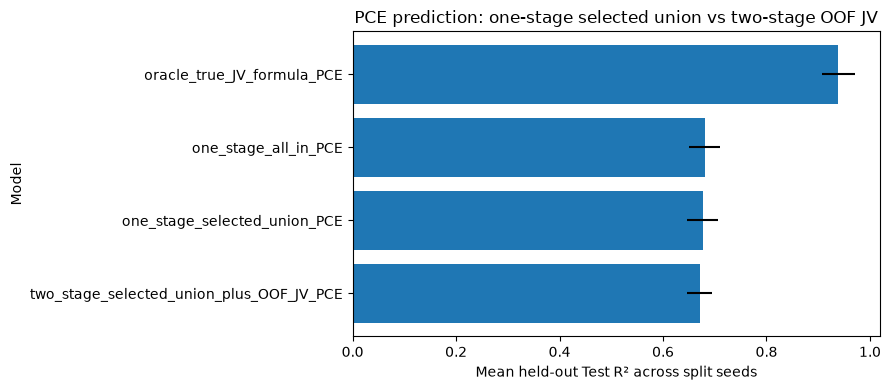

Saved: pce_one_stage_vs_two_stage_canonical207_outputs/plot_pce_model_mean_r2.png


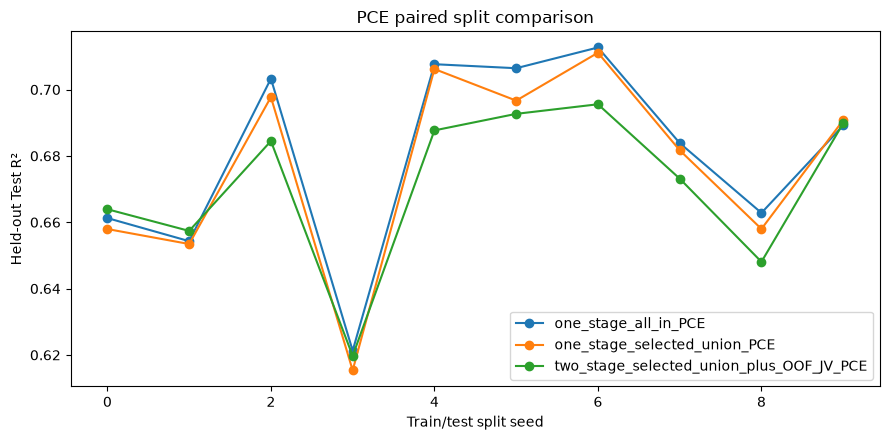

Saved: pce_one_stage_vs_two_stage_canonical207_outputs/plot_pce_paired_split_r2.png


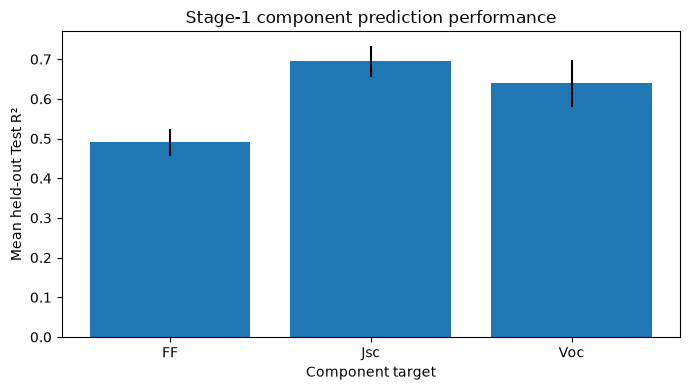

Saved: pce_one_stage_vs_two_stage_canonical207_outputs/plot_stage1_component_mean_r2.png


In [9]:

# ============================================================
# 8. Plots
# ============================================================

# Mean PCE R2 by model.
plot_df = pce_summary.sort_values("PCE_R2_mean", ascending=True)

plt.figure(figsize=(9, max(4, 0.45 * len(plot_df))))
plt.barh(plot_df["model"], plot_df["PCE_R2_mean"], xerr=plot_df["PCE_R2_std"])
plt.xlabel("Mean held-out Test R² across split seeds")
plt.ylabel("Model")
plt.title("PCE prediction: one-stage selected union vs two-stage OOF JV")
plt.tight_layout()
out_path = OUTPUT_DIR / "plot_pce_model_mean_r2.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

# Paired split comparison for the main models.
main_models = [
    "one_stage_all_in_PCE",
    "one_stage_selected_union_PCE",
    "two_stage_selected_union_plus_OOF_JV_PCE",
]
paired = pce_results[pce_results["model"].isin(main_models)].copy()

plt.figure(figsize=(9, 4.5))
for model_name in main_models:
    d = paired[paired["model"] == model_name].sort_values("split_seed")
    plt.plot(d["split_seed"], d["PCE_R2"], marker="o", label=model_name)
plt.xlabel("Train/test split seed")
plt.ylabel("Held-out Test R²")
plt.title("PCE paired split comparison")
plt.legend()
plt.tight_layout()
out_path = OUTPUT_DIR / "plot_pce_paired_split_r2.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

# Stage-1 component performance.
stage_plot = stage1_summary.sort_values("component")
plt.figure(figsize=(7, 4))
plt.bar(stage_plot["component"], stage_plot["test_R2_mean"], yerr=stage_plot["test_R2_std"])
plt.xlabel("Component target")
plt.ylabel("Mean held-out Test R²")
plt.title("Stage-1 component prediction performance")
plt.tight_layout()
out_path = OUTPUT_DIR / "plot_stage1_component_mean_r2.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_path)


In [10]:

# ============================================================
# 9. Optional permutation importance for selected PCE models only
# ============================================================

if RUN_PERMUTATION_IMPORTANCE:
    perm_rows = []

    for split_seed in PERMUTATION_SEEDS:
        print("\n" + "=" * 100)
        print(f"Permutation split seed {split_seed}")
        print("=" * 100)

        idx = np.arange(len(y_pce))
        train_idx, test_idx = train_test_split(
            idx,
            test_size=TEST_SIZE,
            random_state=split_seed,
            shuffle=True,
        )

        y_train_pce = y_pce.iloc[train_idx].reset_index(drop=True)
        y_test_pce = y_pce.iloc[test_idx].reset_index(drop=True)
        Y_train_comp = Y_comp.iloc[train_idx].reset_index(drop=True)

        X_train_sel = X_pce_selected.iloc[train_idx].reset_index(drop=True)
        X_test_sel = X_pce_selected.iloc[test_idx].reset_index(drop=True)

        inner_cv = KFold(n_splits=INNER_CV_SPLITS, shuffle=True, random_state=split_seed)
        train_stage1_pred = pd.DataFrame(index=np.arange(len(train_idx)))
        test_stage1_pred = pd.DataFrame(index=np.arange(len(test_idx)))

        for component, target_col in TARGETS.items():
            X_comp_all, _ = get_component_feature_matrix(component)
            X_comp_train = X_comp_all.iloc[train_idx].reset_index(drop=True)
            X_comp_test = X_comp_all.iloc[test_idx].reset_index(drop=True)
            y_comp_train = Y_train_comp[target_col].reset_index(drop=True)

            comp_model_for_oof = make_rf_pipeline(X_comp_train, rf_random_state=RF_RANDOM_STATE)
            train_stage1_pred[f"{component}_hat"] = cross_val_predict(
                comp_model_for_oof,
                X_comp_train,
                y_comp_train,
                cv=inner_cv,
                n_jobs=1,
            )

            comp_final_model = make_rf_pipeline(X_comp_train, rf_random_state=RF_RANDOM_STATE)
            comp_final_model.fit(X_comp_train, y_comp_train)
            test_stage1_pred[f"{component}_hat"] = comp_final_model.predict(X_comp_test)

        model_inputs = {
            "one_stage_selected_union_PCE": (X_train_sel, X_test_sel),
            "two_stage_selected_union_plus_OOF_JV_PCE": (
                pd.concat([X_train_sel.reset_index(drop=True), train_stage1_pred.reset_index(drop=True)], axis=1),
                pd.concat([X_test_sel.reset_index(drop=True), test_stage1_pred.reset_index(drop=True)], axis=1),
            ),
        }

        for model_name, (X_train_model, X_test_model) in model_inputs.items():
            model = make_rf_pipeline(X_train_model, rf_random_state=RF_RANDOM_STATE)
            model.fit(X_train_model, y_train_pce)

            perm = permutation_importance(
                model,
                X_test_model,
                y_test_pce,
                scoring="r2",
                n_repeats=PERMUTATION_N_REPEATS,
                random_state=split_seed,
                n_jobs=1,
            )

            for feature, imp_mean, imp_std in zip(
                X_test_model.columns,
                perm.importances_mean,
                perm.importances_std,
            ):
                perm_rows.append({
                    "split_seed": split_seed,
                    "model": model_name,
                    "feature": feature,
                    "importance_mean": float(imp_mean),
                    "importance_std_within_seed": float(imp_std),
                })

    perm_df = pd.DataFrame(perm_rows)
    perm_df.to_csv(OUTPUT_DIR / "pce_selected_permutation.csv", index=False)

    perm_summary = (
        perm_df
        .groupby(["model", "feature"])
        .agg(
            n_splits=("split_seed", "nunique"),
            importance_mean_across_splits=("importance_mean", "mean"),
            importance_std_across_splits=("importance_mean", "std"),
            importance_min=("importance_mean", "min"),
            importance_max=("importance_mean", "max"),
        )
        .reset_index()
        .sort_values(["model", "importance_mean_across_splits"], ascending=[True, False])
    )
    perm_summary.to_csv(OUTPUT_DIR / "pce_selected_permutation_summary.csv", index=False)

    for model_name in perm_summary["model"].unique():
        print("\n" + "=" * 100)
        print(model_name)
        print("=" * 100)
        display(perm_summary[perm_summary["model"] == model_name].head(25))

else:
    print("Permutation importance skipped. Set RUN_PERMUTATION_IMPORTANCE=True to run selected-model permutation only.")



Permutation split seed 0

Permutation split seed 1

Permutation split seed 2

Permutation split seed 3

Permutation split seed 4

Permutation split seed 5

Permutation split seed 6

Permutation split seed 7

Permutation split seed 8

Permutation split seed 9

one_stage_selected_union_PCE


,model,feature,n_splits,importance_mean_across_splits,importance_std_across_splits,importance_min,importance_max
26,one_stage_selected_union_PCE,perovskite_bandgap_clean,10,0.250860,0.066872,0.155925,0.378163
0,one_stage_selected_union_PCE,Absorber_to_ETL_ratio,10,0.133871,0.038118,0.079362,0.185201
5,one_stage_selected_union_PCE,PVK_thickness_clean,10,0.080332,0.018296,0.060270,0.119658
29,one_stage_selected_union_PCE,perovskite_deposition.quenching_media,10,0.061837,0.024421,0.023493,0.112903
13,one_stage_selected_union_PCE,ff_PVK_fraction_of_total_stack,10,0.026348,0.013009,0.004669,0.041069
4,one_stage_selected_union_PCE,HTL_thickness_clean,10,0.026063,0.006762,0.012255,0.036086
1,one_stage_selected_union_PCE,BC_thickness_clean,10,0.021866,0.008458,0.009550,0.034005
30,one_stage_selected_union_PCE,perovskite_deposition.solvents,10,0.016661,0.008039,0.007294,0.036393
9,one_stage_selected_union_PCE,eqe.measured,10,0.014583,0.006153,0.007161,0.026741
36,one_stage_selected_union_PCE,stability.measured,10,0.013042,0.003862,0.008162,0.020500



two_stage_selected_union_plus_OOF_JV_PCE


,model,feature,n_splits,importance_mean_across_splits,importance_std_across_splits,importance_min,importance_max
43,two_stage_selected_union_plus_OOF_JV_PCE,Jsc_hat,10,0.466374,0.038787,0.390414,0.526009
41,two_stage_selected_union_plus_OOF_JV_PCE,FF_hat,10,0.159571,0.017203,0.128748,0.184084
45,two_stage_selected_union_plus_OOF_JV_PCE,Voc_hat,10,0.121674,0.017715,0.086285,0.141002
66,two_stage_selected_union_plus_OOF_JV_PCE,perovskite_bandgap_clean,10,0.003638,0.005133,-0.001687,0.014422
76,two_stage_selected_union_plus_OOF_JV_PCE,stability.measured,10,0.003292,0.001115,0.001083,0.004993
49,two_stage_selected_union_plus_OOF_JV_PCE,eqe.measured,10,0.002149,0.001780,0.000379,0.004822
48,two_stage_selected_union_plus_OOF_JV_PCE,cell.stack_sequence,10,0.001558,0.002691,-0.003924,0.004685
51,two_stage_selected_union_plus_OOF_JV_PCE,etl.deposition_procedure,10,0.001166,0.003399,-0.003266,0.006460
42,two_stage_selected_union_plus_OOF_JV_PCE,HTL_thickness_clean,10,0.001096,0.001760,-0.001605,0.004569
47,two_stage_selected_union_plus_OOF_JV_PCE,cell.area_measured,10,0.000718,0.002015,-0.002228,0.003832


# Plot permutation importance for the two selected-union PCE models

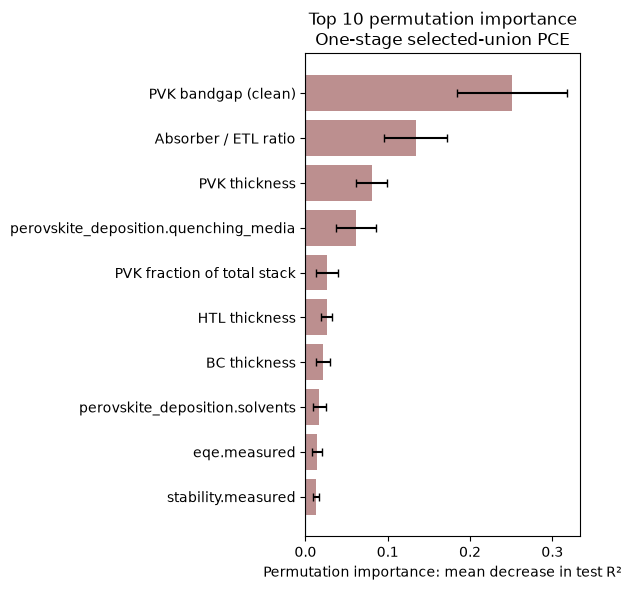

Saved: pce_one_stage_vs_two_stage_canonical207_outputs/plot_perm_top10_one_stage_selected_union_PCE.png
Saved: pce_one_stage_vs_two_stage_canonical207_outputs/plot_perm_top10_one_stage_selected_union_PCE.pdf


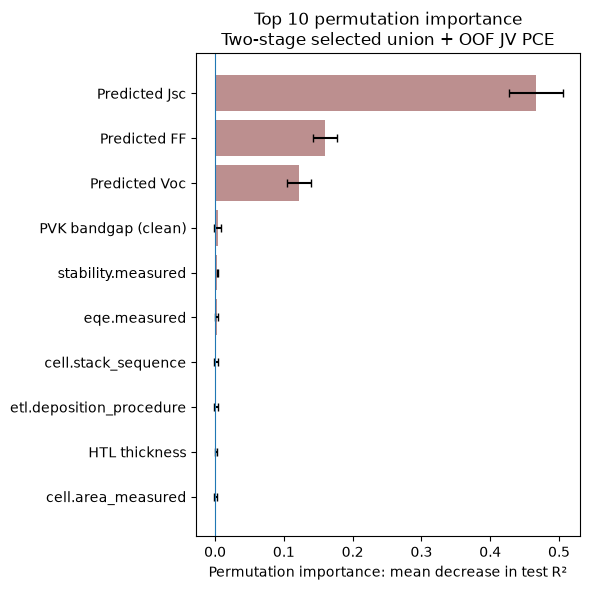

Saved: pce_one_stage_vs_two_stage_canonical207_outputs/plot_perm_top10_two_stage_selected_union_plus_OOF_JV_PCE.png
Saved: pce_one_stage_vs_two_stage_canonical207_outputs/plot_perm_top10_two_stage_selected_union_plus_OOF_JV_PCE.pdf


In [11]:
# ============================================================
# Plot top-N PCE permutation importance for slides
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("pce_one_stage_vs_two_stage_canonical207_outputs")

perm_path = OUTPUT_DIR / "pce_selected_permutation_summary.csv"
perm_summary = pd.read_csv(perm_path)

TOP_N = 10

MODEL_LABELS = {
    "one_stage_selected_union_PCE": "One-stage selected-union PCE",
    "two_stage_selected_union_plus_OOF_JV_PCE": "Two-stage selected union + OOF JV PCE",
}

def pretty_feature_name(x):
    replacements = {
        "Absorber_to_ETL_ratio": "Absorber / ETL ratio",
        "ff_PVK_fraction_of_total_stack": "PVK fraction of total stack",
        "perovskite_bandgap_clean": "PVK bandgap (clean)",
        "PVK_thickness_clean": "PVK thickness",
        "ETL_thickness_clean": "ETL thickness",
        "HTL_thickness_clean": "HTL thickness",
        "BC_thickness_clean": "BC thickness",
        "Jsc_hat": "Predicted Jsc",
        "Voc_hat": "Predicted Voc",
        "FF_hat": "Predicted FF",
    }
    return replacements.get(x, x)

def plot_perm_topn(model_name, top_n=10):
    d = (
        perm_summary
        .loc[perm_summary["model"] == model_name]
        .sort_values("importance_mean_across_splits", ascending=False)
        .head(top_n)
        .copy()
    )

    d["plot_name"] = d["feature"].map(pretty_feature_name)
    d["importance_std_across_splits"] = d["importance_std_across_splits"].fillna(0)

    # reverse so largest appears at top
    d = d.iloc[::-1]

    plt.figure(figsize=(6, 6))
    plt.barh(
        d["plot_name"],
        d["importance_mean_across_splits"],
        xerr=d["importance_std_across_splits"],
        capsize=3, color='rosybrown'
    )

    plt.xlabel("Permutation importance: mean decrease in test R²")
    plt.ylabel("")
    plt.title(f"Top {top_n} permutation importance\n{MODEL_LABELS.get(model_name, model_name)}")
    plt.axvline(0, linewidth=0.8)
    plt.tight_layout()

    out_png = OUTPUT_DIR / f"plot_perm_top{top_n}_{model_name}.png"
    out_pdf = OUTPUT_DIR / f"plot_perm_top{top_n}_{model_name}.pdf"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)
    print("Saved:", out_pdf)

plot_perm_topn("one_stage_selected_union_PCE", top_n=TOP_N)
plot_perm_topn("two_stage_selected_union_plus_OOF_JV_PCE", top_n=TOP_N)